# Unified treatment of all our hypotheses:
# 2. Hypothesis: $Y = A Q B$, with $A = diag(\lambda)$, $B = diag(\phi)$, with SVD $Y = U S V^t$, 
# with $S = diag(\psi)$, and $Q$, $U$, $V$ all orthogonal. 
# Which of the following are true, as $d \rightarrow \infty$?
# 2.1 : $(Tr(Y))^2 / Tr(Y^2) \rightarrow \nu(\psi)$
# 2.2 : $Tr(Y) / Tr(S) \rightarrow 1$
# 2.3 : $Tr(Y^2) / Tr(S^2) \rightarrow 1$
# 2.4 : Does uniform / Cauchy / Pareto make any difference?
# 2.5 : If $\lambda \sim Pareto(\alpha)$, and $\phi \sim Pareto(\beta)$, 
# does convergence depend on $\alpha$, $\beta$?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

import PatnaikPearson as pp
import cupy

# 2 (i) Uniform

In [2]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQB"] = True
this_config["A_diagonal"] = True
this_config["A_uniform"] = True
this_config["B_diagonal"] = True
this_config["B_uniform"] = True

min_d = 10
max_d = 1000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

xx_AQB_u_d_10_1000 = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[1.]
[1.]
generating A
A is diagonal
A is uniform
generating B
B is diagonal
B is uniform
A.shape =  (10, 10)
Q.shape =  (10, 10)
B.shape =  (10, 10)
Qt.shape =  (10, 10)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
generating A
A is diagonal
A is uniform
generating B
B is diagonal
B is uniform
A.shape =  (10, 10)
Q.shape =  (10, 10)
B.shape =  (10, 10)
Qt.shape =  (10, 10)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calc

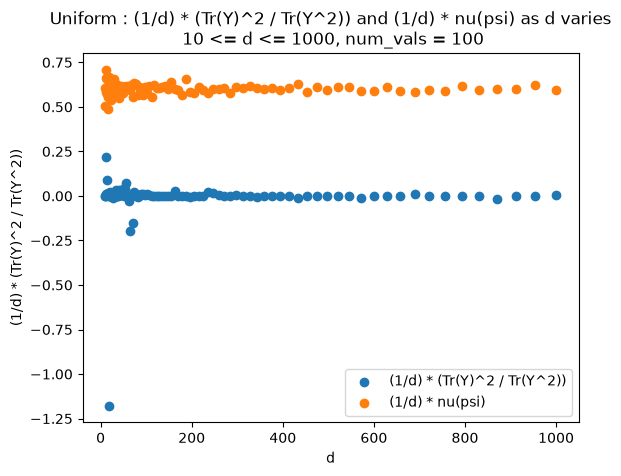

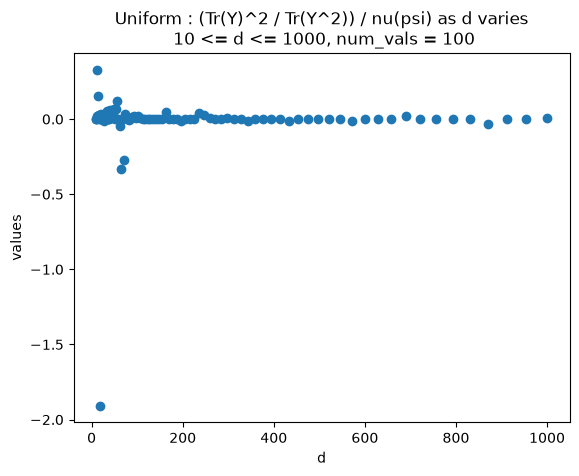

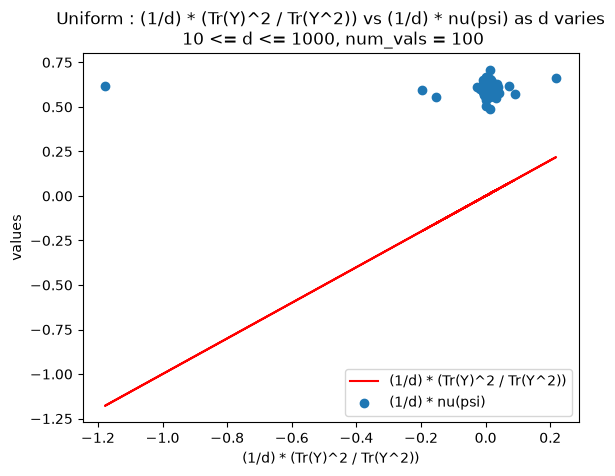

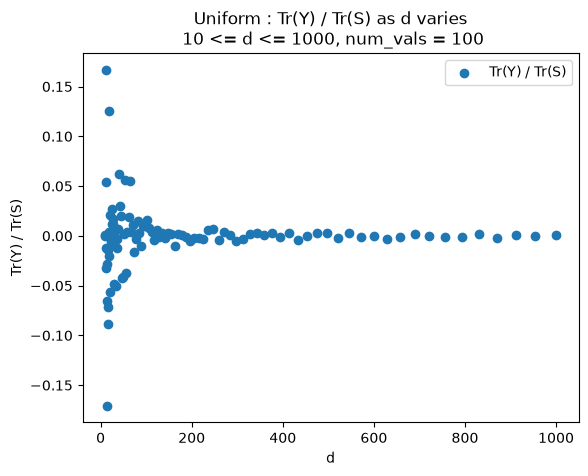

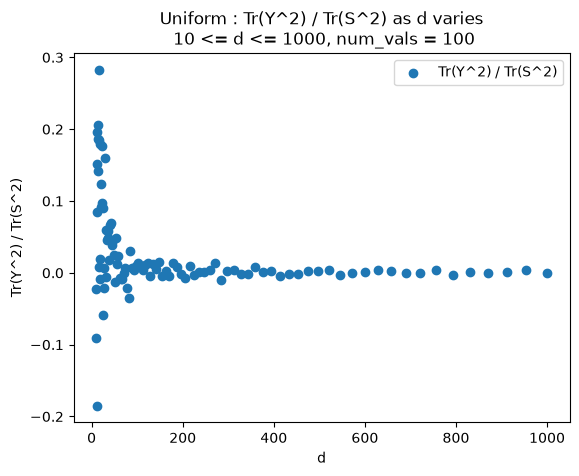

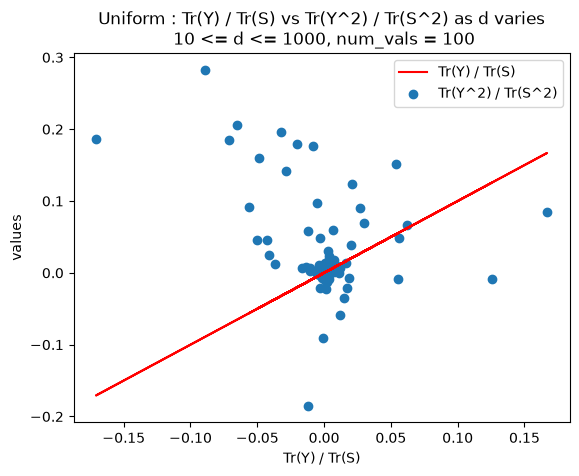

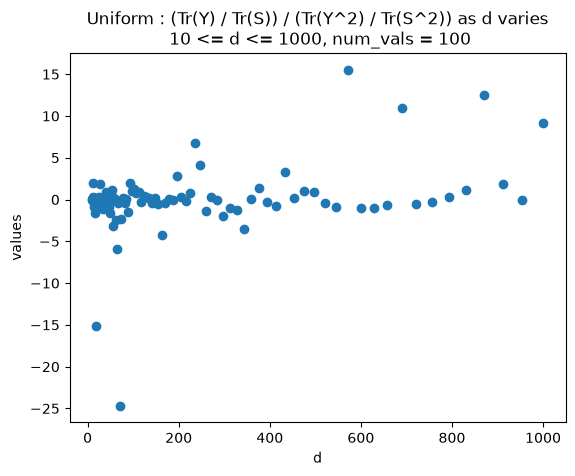

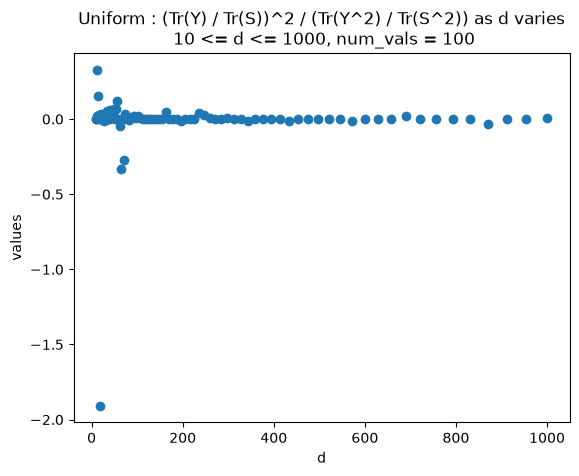

In [3]:
pp.plot_one(xx_AQB_u_d_10_1000, "Uniform")

# (ii) Cauchy

In [4]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQB"] = True
this_config["A_diagonal"] = True
this_config["A_cauchy"] = True
this_config["B_diagonal"] = True
this_config["B_cauchy"] = True

min_d = 10
max_d = 1000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

xx_AQB_c_d_10_1000 = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[1.]
[1.]
generating A
A is diagonal
A is Cauchy
generating B
B is diagonal
B is Cauchy
A.shape =  (10, 10)
Q.shape =  (10, 10)
B.shape =  (10, 10)
Qt.shape =  (10, 10)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
generating A
A is diagonal
A is Cauchy
generating B
B is diagonal
B is Cauchy
A.shape =  (10, 10)
Q.shape =  (10, 10)
B.shape =  (10, 10)
Qt.shape =  (10, 10)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculat

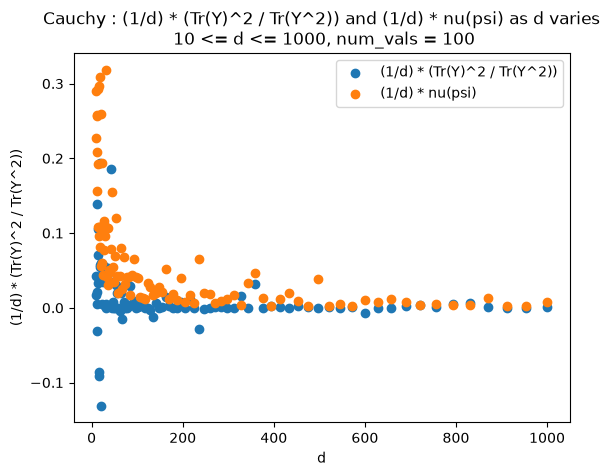

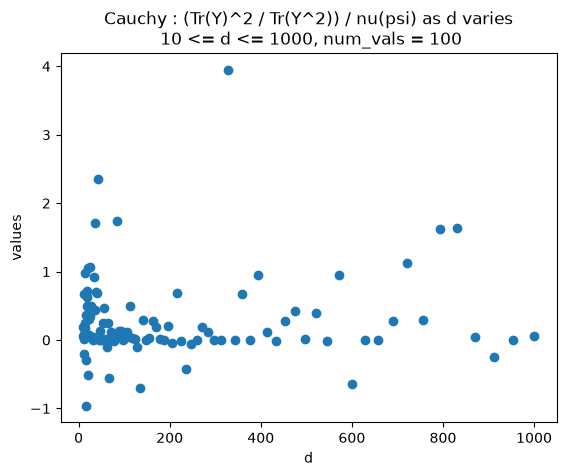

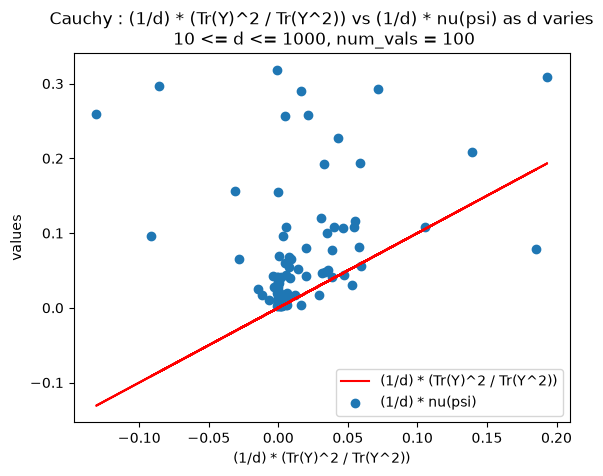

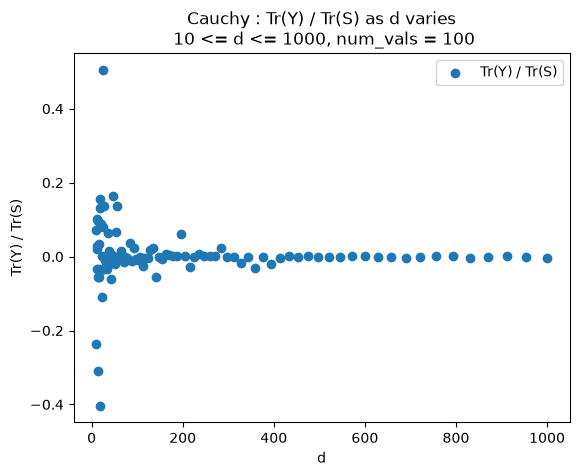

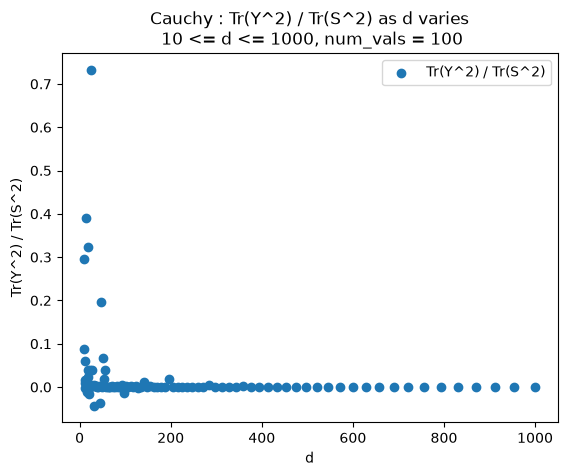

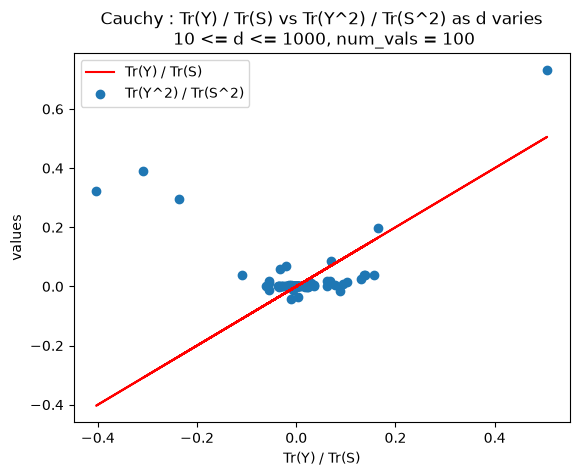

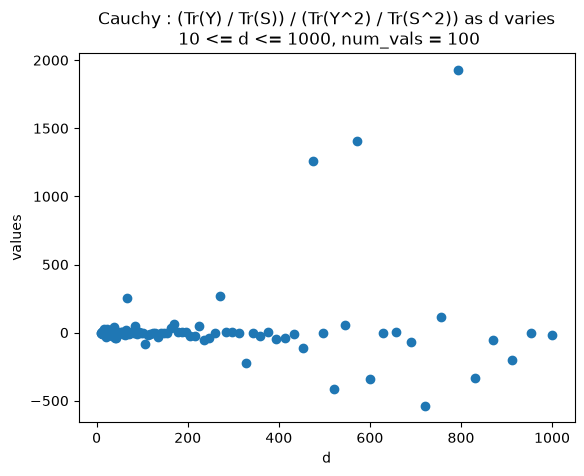

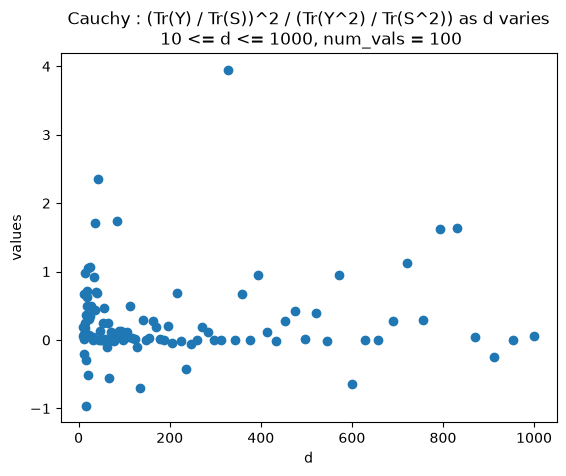

In [5]:
pp.plot_one(xx_AQB_c_d_10_1000, "Cauchy")

# (iii) Pareto, fix alpha, beta, allow d to vary

In [9]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQB"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 10
max_d = 1000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 2.0
B_beta = 3.0
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx_AQB_p_20_30_d_10_1000 = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2.]
[3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3.]
generating A
A is diagonal
A is

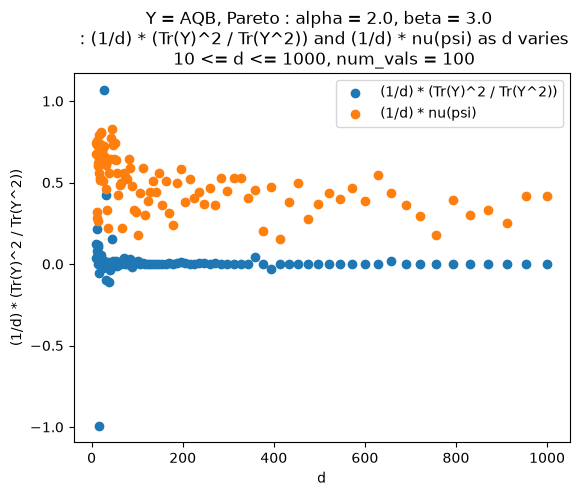

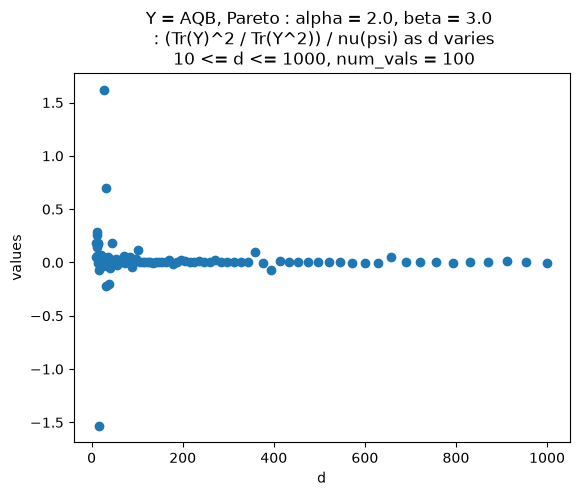

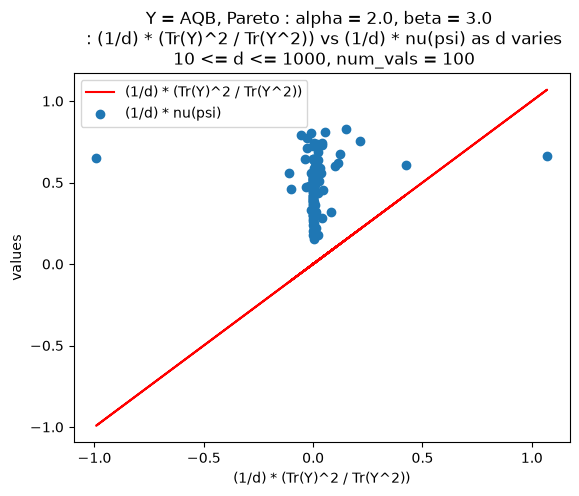

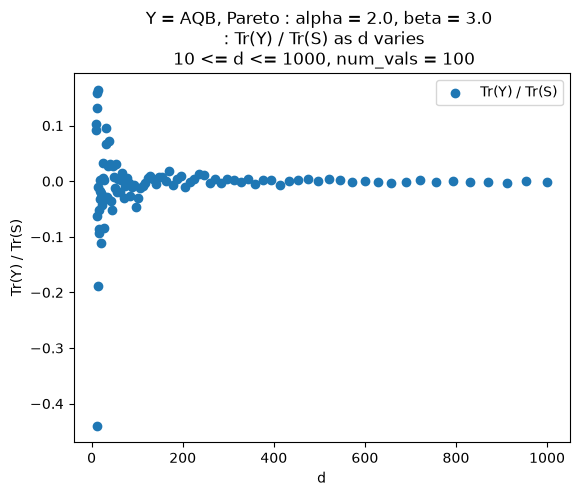

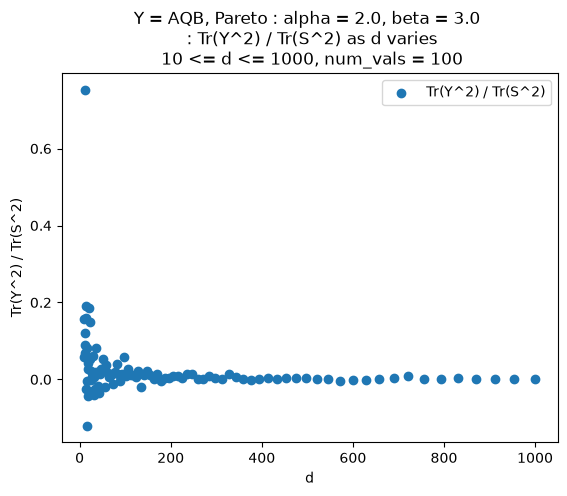

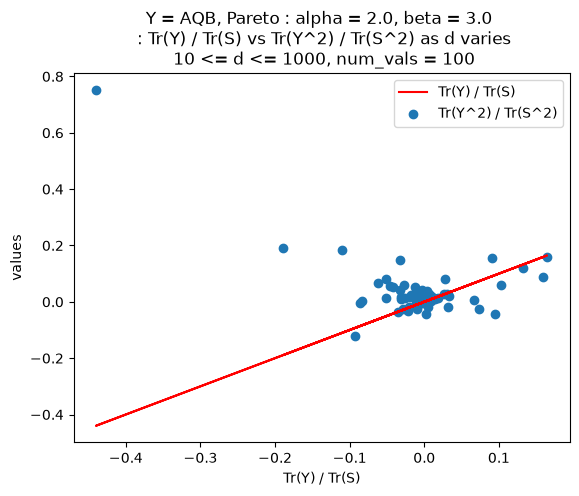

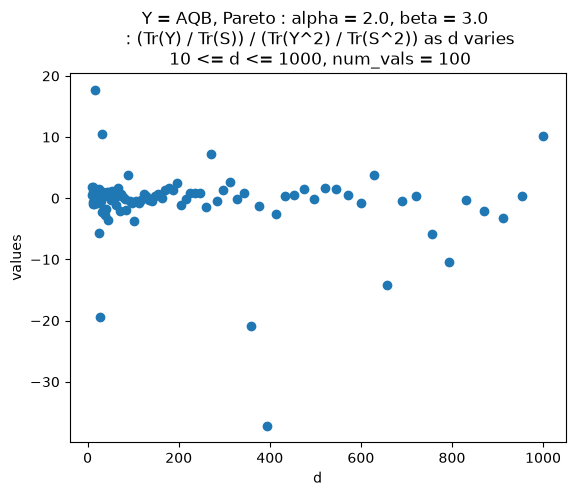

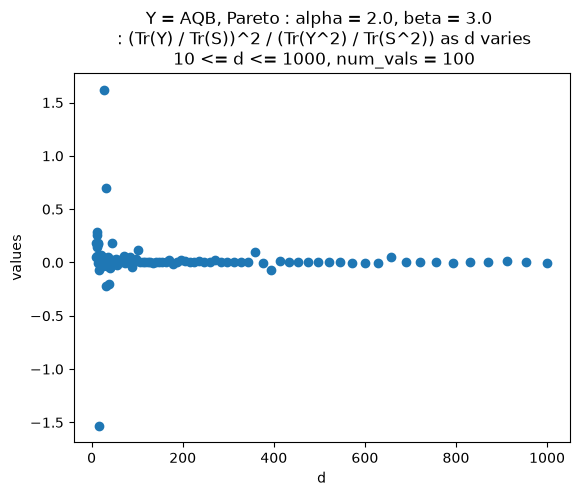

In [10]:
pp.plot_one(xx_AQB_p_20_30_d_10_1000, "Y = AQB, Pareto : alpha = 2.0, beta = 3.0 \n")

In [11]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQB"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 10
max_d = 1000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 1.1
B_beta = 1.1
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx_AQB_p_11_11_d_10_1000 = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1
 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1
 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1
 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1
 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1
 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1]
[1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1
 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1
 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1 1.1
 1.1 1.1 1.1 1.1 

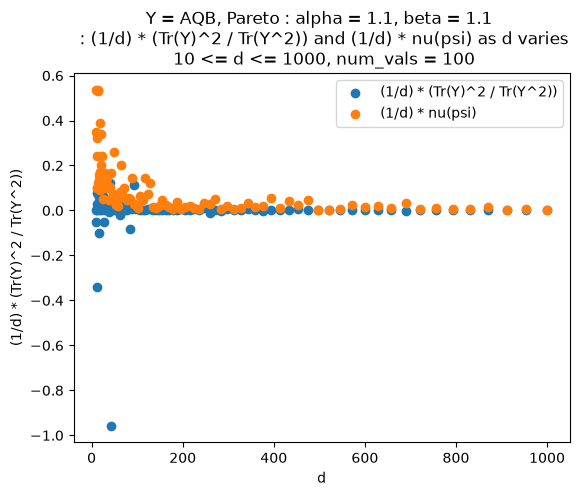

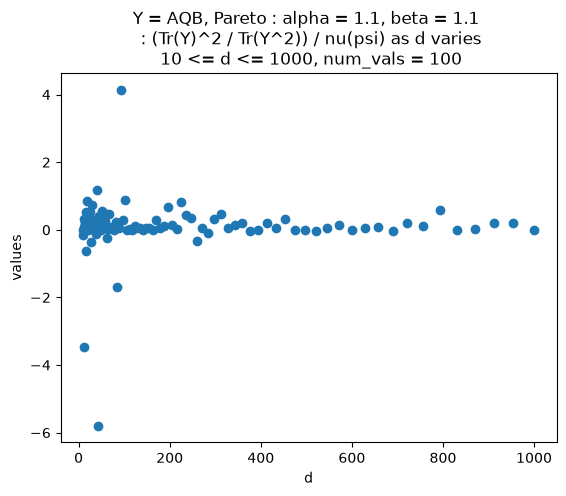

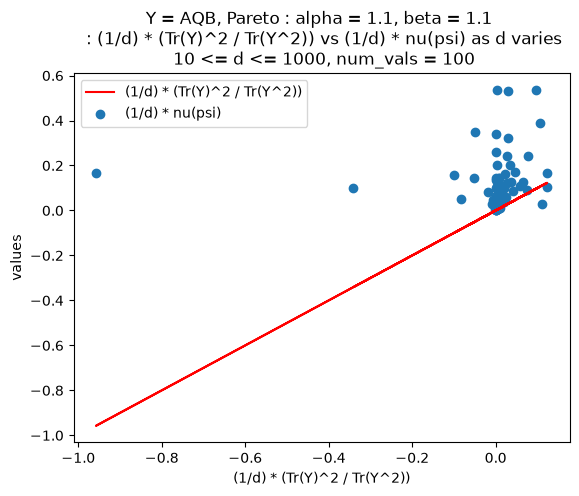

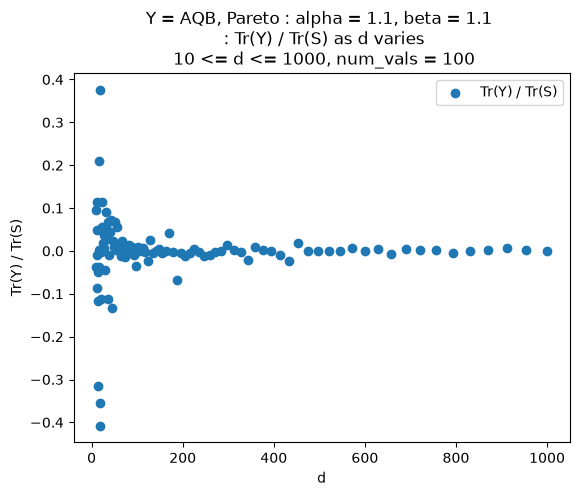

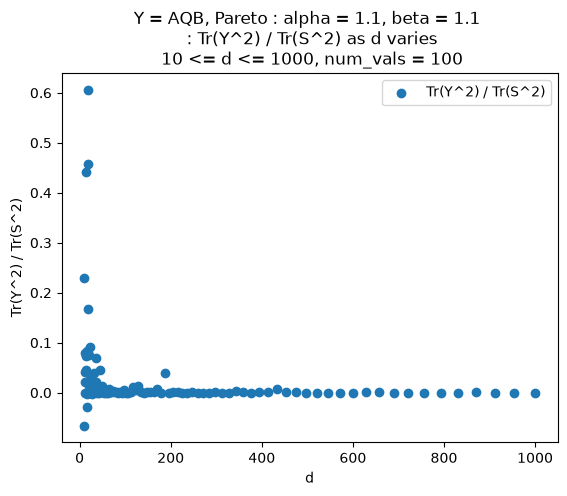

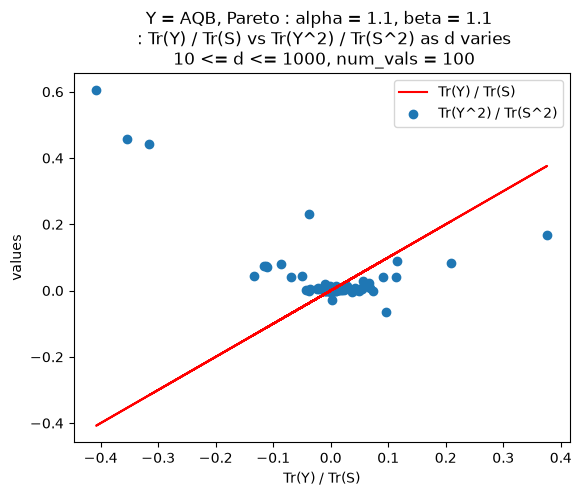

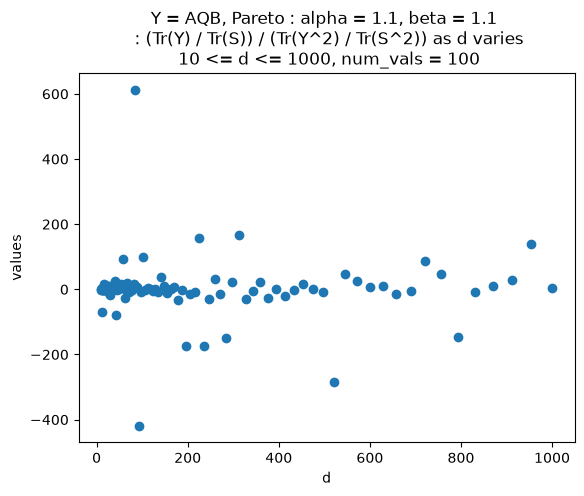

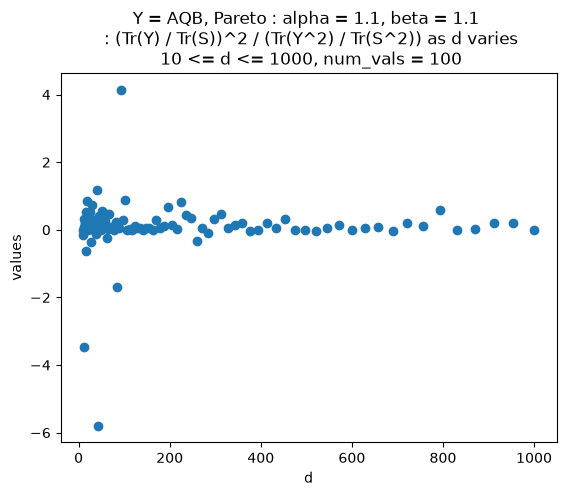

In [12]:
pp.plot_one(xx_AQB_p_11_11_d_10_1000, "Y = AQB, Pareto : alpha = 1.1, beta = 1.1 \n")

# Now fix d, and take alpha = beta, varying between 0.1 and 5.0

In [13]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQB"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

this_config["A_pareto_alpha_vals"] = np.arange(0.1,3.5,0.02)
this_config["B_pareto_beta_vals"] = this_config["A_pareto_alpha_vals"]

fixed_d = 100
d_vals = fixed_d * np.ones(len(this_config["A_pareto_alpha_vals"]))
this_config["d_vals"] = d_vals

xx_AQB_p_aeqb_01_35_d_100 = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28 0.3  0.32 0.34 0.36
 0.38 0.4  0.42 0.44 0.46 0.48 0.5  0.52 0.54 0.56 0.58 0.6  0.62 0.64
 0.66 0.68 0.7  0.72 0.74 0.76 0.78 0.8  0.82 0.84 0.86 0.88 0.9  0.92
 0.94 0.96 0.98 1.   1.02 1.04 1.06 1.08 1.1  1.12 1.14 1.16 1.18 1.2
 1.22 1.24 1.26 1.28 1.3  1.32 1.34 1.36 1.38 1.4  1.42 1.44 1.46 1.48
 1.5  1.52 1.54 1.56 1.58 1.6  1.62 1.64 1.66 1.68 1.7  1.72 1.74 1.76
 1.78 1.8  1.82 1.84 1.86 1.88 1.9  1.92 1.94 1.96 1.98 2.   2.02 2.04
 2.06 2.08 2.1  2.12 2.14 2.16 2.18 2.2  2.22 2.24 2.26 2.28 2.3  2.32
 2.34 2.36 2.38 2.4  2.42 2.44 2.46 2.48 2.5  2.52 2.54 2.56 2.58 2.6
 2.62 

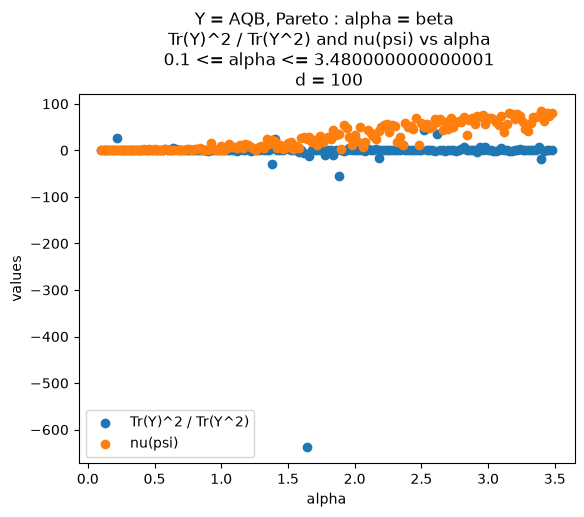

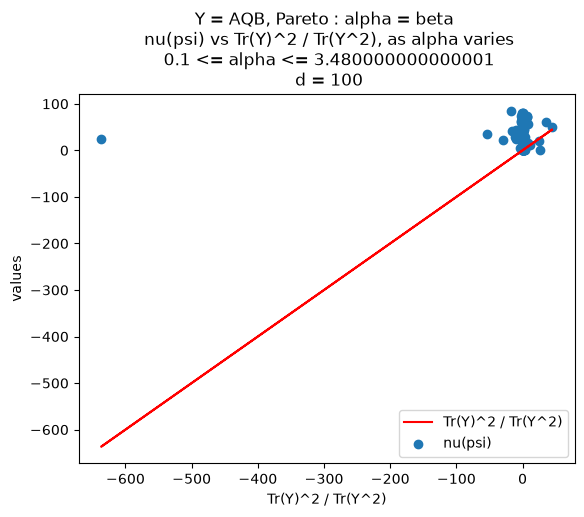

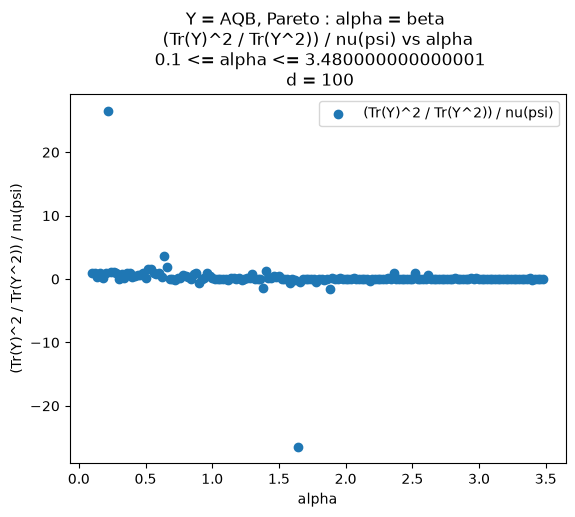

In [15]:
this_prefix = "Y = AQB, Pareto : alpha = beta \n"
pp.plot_two(xx_AQB_p_aeqb_01_35_d_100, this_prefix)

In [16]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQB"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

this_config["A_pareto_alpha_vals"] = np.arange(0.9,1.41,0.01)
this_config["B_pareto_beta_vals"] = this_config["A_pareto_alpha_vals"]

fixed_d = 100
d_vals = fixed_d * np.ones(len(this_config["A_pareto_alpha_vals"]))
this_config["d_vals"] = d_vals

xx_AQB_p_aeqb_09_14_d_100 = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.   1.01 1.02 1.03
 1.04 1.05 1.06 1.07 1.08 1.09 1.1  1.11 1.12 1.13 1.14 1.15 1.16 1.17
 1.18 1.19 1.2  1.21 1.22 1.23 1.24 1.25 1.26 1.27 1.28 1.29 1.3  1.31
 1.32 1.33 1.34 1.35 1.36 1.37 1.38 1.39 1.4 ]
[0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.   1.01 1.02 1.03
 1.04 1.05 1.06 1.07 1.08 1.09 1.1  1.11 1.12 1.13 1.14 1.15 1.16 1.17
 1.18 1.19 1.2  1.21 1.22 1.23 1.24 1.25 1.26 1.27 1.28 1.29 1.3  1.31
 1.32 1.33 1.34 1.35 1.36 1.37 1.38 1.39 1.4 ]
generating A
A is diagonal
A is Pareto
generating B
B is diagonal
B is Pareto
A.shape =  (100, 100)
Q.shape =  (100, 100)
B

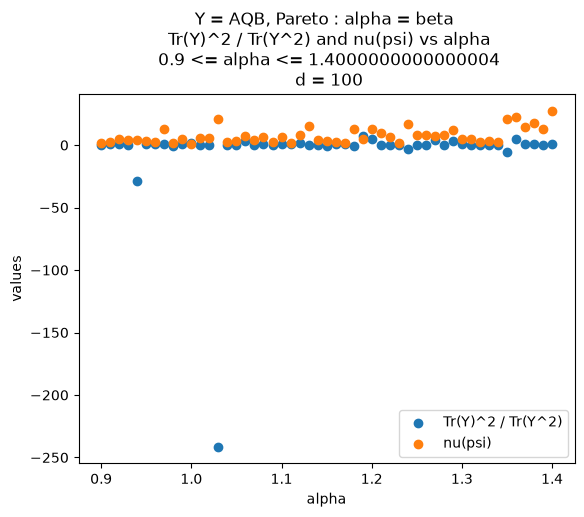

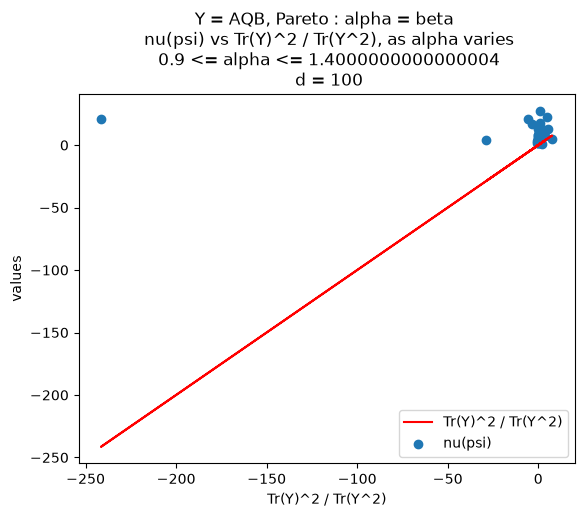

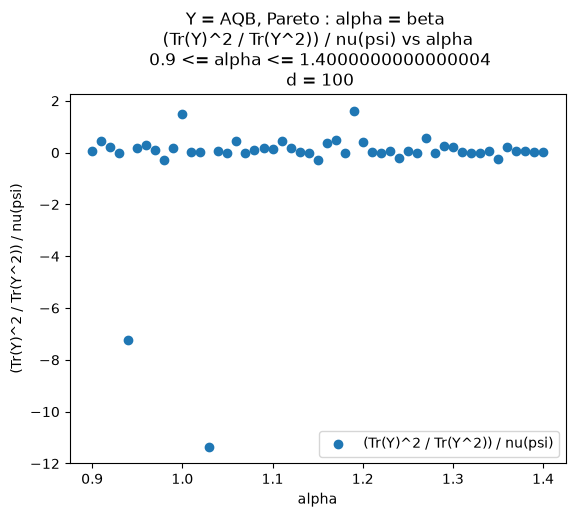

In [18]:
this_prefix = "Y = AQB, Pareto : alpha = beta \n"
pp.plot_two(xx_AQB_p_aeqb_09_14_d_100, this_prefix)

# fix beta, allow alpha to vary

In [19]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQB"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

this_config["A_pareto_alpha_vals"] = np.arange(0.1,2.0,0.01)
this_config["B_pareto_beta_vals"] = 1.15 * np.ones(len(this_config["A_pareto_alpha_vals"]))

fixed_d = 100
d_vals = fixed_d * np.ones(len(this_config["A_pareto_alpha_vals"]))
this_config["d_vals"] = d_vals

xx_AQB_a_01_20_b_115_d_100 = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[0.1  0.11 0.12 0.13 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23
 0.24 0.25 0.26 0.27 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37
 0.38 0.39 0.4  0.41 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51
 0.52 0.53 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65
 0.66 0.67 0.68 0.69 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79
 0.8  0.81 0.82 0.83 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93
 0.94 0.95 0.96 0.97 0.98 0.99 1.   1.01 1.02 1.03 1.04 1.05 1.06 1.07
 1.08 1.09 1.1  1.11 1.12 1.13 1.14 1.15 1.16 1.17 1.18 1.19 1.2  1.21
 1.22 1.23 1.24 1.25 1.26 1.27 1.28 1.29 1.3  1.31 1.32 1.33 1.34 1.35
 1.3

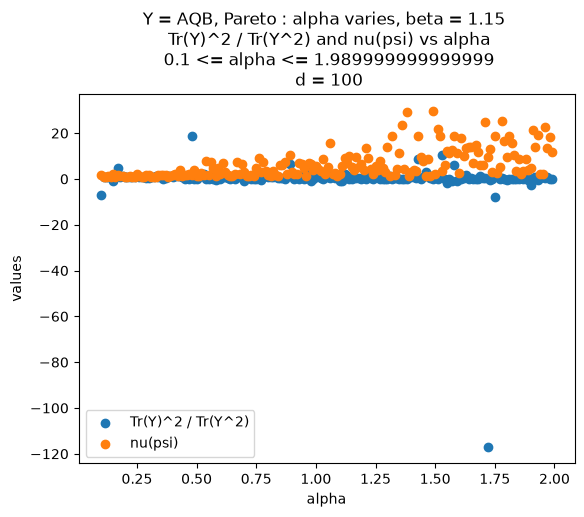

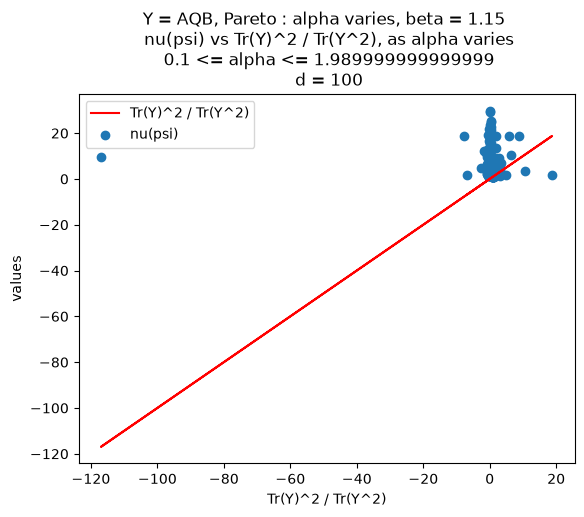

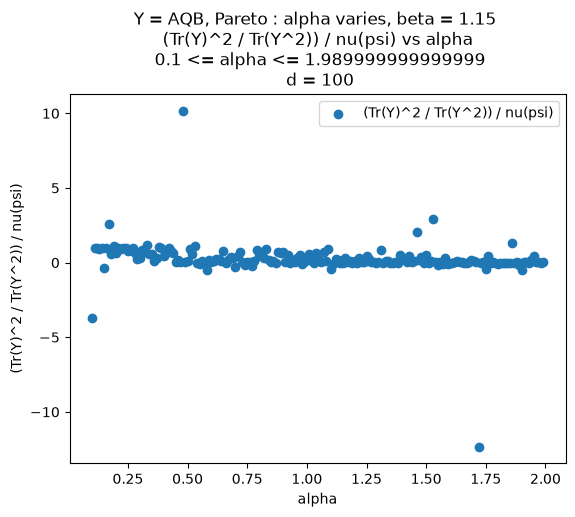

In [20]:
this_prefix = "Y = AQB, Pareto : alpha varies, beta = 1.15 \n"
pp.plot_two(xx_AQB_a_01_20_b_115_d_100, this_prefix)

# Fix alpha = beta = 1.15, and d = 100. Calculate 500 values, plot histogram

In [21]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQB"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

num_alpha_vals = 500
this_config["A_pareto_alpha_vals"] = 1.15 * np.ones(num_alpha_vals)
this_config["B_pareto_beta_vals"] = 1.15 * np.ones(len(this_config["A_pareto_alpha_vals"]))

fixed_d = 100
d_vals = fixed_d * np.ones(len(this_config["A_pareto_alpha_vals"]))
this_config["d_vals"] = d_vals

xx_AQB_aeqb_115_d_100_500_times = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.1

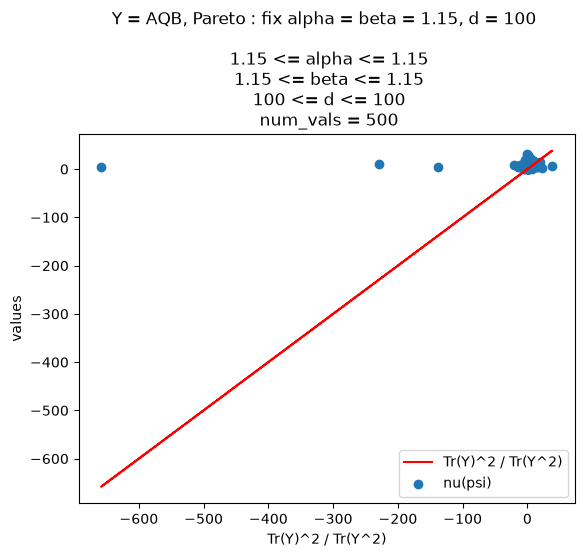


 Statistics for (Tr(Y)^2 / Tr(Y^2)) / nu(psi) 

shape : (500,)
min : -172.50818556720446
max : 10.981756788764665
sum : -139.29257445813755
mean : -0.2785851489162751
std : 8.034988343312634
norm : 179.77575943709232
summary stats for input values
type : <class 'numpy.ndarray'>
shape : (500,)
min : -172.50818556720446
max : 10.981756788764665
mean : -0.2785
std : 8.0349
Histogram counts: [  0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0
   0   0   1   0   0   0   0   0   0   0   0   5  17 460  10   2   2   1
   0   0   0   0   0   0   0   0   0   0]


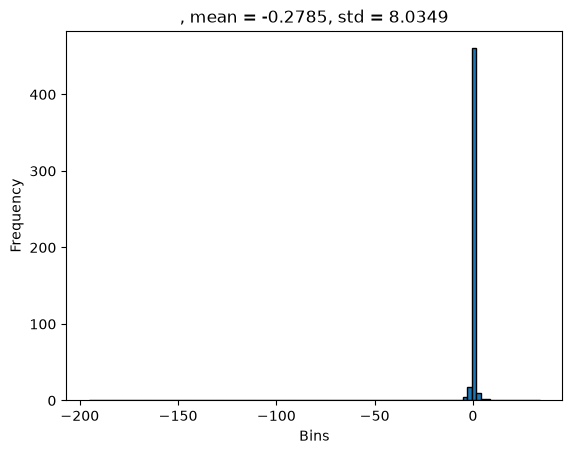

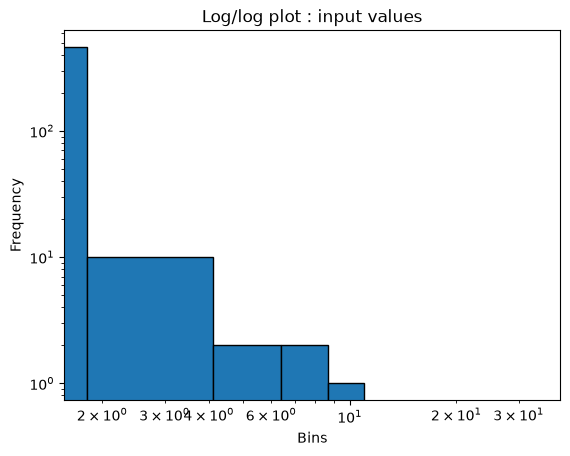

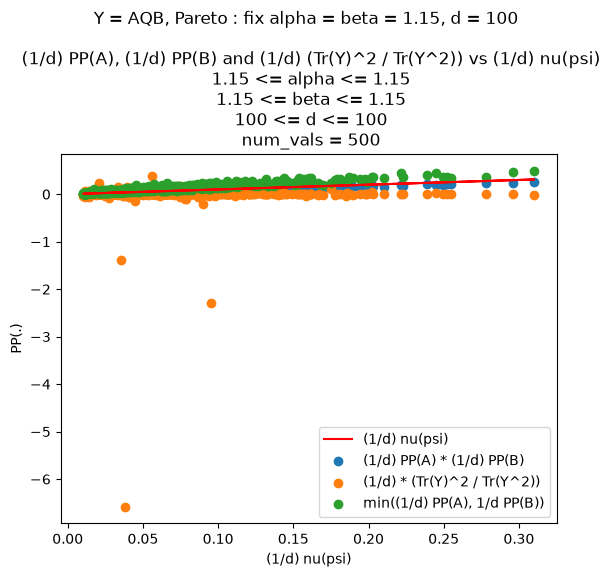

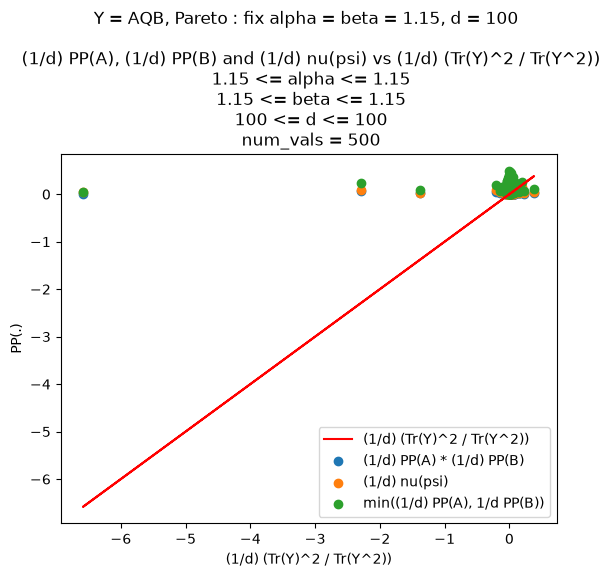

In [23]:
this_prefix = "Y = AQB, Pareto : fix alpha = beta = 1.15, d = 100 \n"
pp.plot_three(xx_AQB_aeqb_115_d_100_500_times, this_prefix)